In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

In [17]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, confusion_matrix,
    f1_score, accuracy_score, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SklearnPipeline
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

### Loading Data

In [2]:
df = pd.read_csv('../data/processed/station2_labelled.csv')

FEATURES     = ['DO', 'PH', 'AMMONIA(mg/l)', 'TEMP', 'NITRATE(PPM)', 'TURBIDITY']
TARGET       = 'feed_label'
CLASS_NAMES  = ['Prime Feed', 'Reduce Feed', 'Halt Feeding']

X = df[FEATURES]
y = df[TARGET]

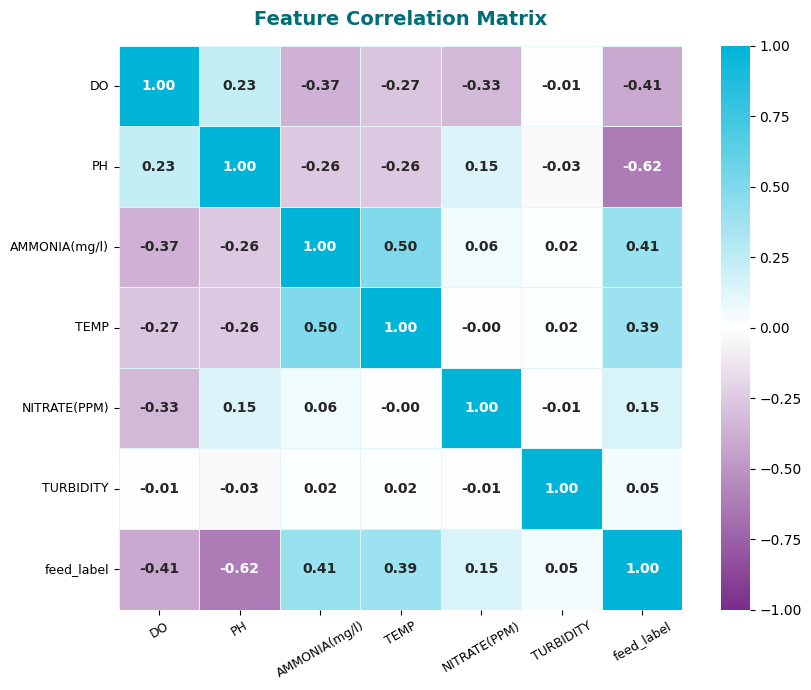

In [14]:
corr_cols = FEATURES + ['feed_label']
corr      = df[corr_cols].corr()

# Custom aqua diverging colormap
aqua_cmap = LinearSegmentedColormap.from_list(
    'aqua_div', ['#7b2d8b', '#ffffff', '#00b4d8']
)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap=aqua_cmap,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor='#e0f7fa',
    square=True,
    annot_kws={'size': 10, 'weight': 'bold'},
    ax=ax
)

ax.set_title('Feature Correlation Matrix', fontsize=14,
             fontweight='bold', pad=15, color='#006d77')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.show()

### Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

### Smote on the training Set 

In [7]:
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape}")
print(f"After  SMOTE : {X_bal.shape}")

Before SMOTE : (20343, 6)
After  SMOTE : (23694, 6)


### Model Definition

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {

    # Tree-based 
    'Decision Tree': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   DecisionTreeClassifier(
                      max_depth=10, min_samples_leaf=10,
                      class_weight='balanced', random_state=42))
    ]),

    'Random Forest': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   RandomForestClassifier(
                      n_estimators=300, max_depth=12, min_samples_leaf=5,
                      max_features='sqrt', class_weight='balanced',
                      random_state=42, n_jobs=-1))
    ]),

    'XGBoost': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   XGBClassifier(
                      n_estimators=300, max_depth=6, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                      eval_metric='mlogloss', random_state=42, n_jobs=-1))
    ]),

    # Non-tree (SMOTE  scale  model)
    'Logistic Regression': Pipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
                       max_iter=1000, class_weight='balanced', random_state=42))
    ]),

    'SVM': Pipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    SVC(
                       kernel='rbf', class_weight='balanced',
                       probability=True, random_state=42))
    ]),

    'KNN': Pipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=7, n_jobs=-1))
    ]),
}

### Cross Validation (all pipelines evaluated on raw X_train / y_train)

In [10]:
print("Cross-Validation Results (F1 Macro)\n" + "─" * 45)

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    print(f"{name:<22}  mean={scores.mean():.4f}  (+/- {scores.std():.4f})")

Cross-Validation Results (F1 Macro)
─────────────────────────────────────────────
Decision Tree           mean=0.9890  (+/- 0.0016)
Random Forest           mean=0.9904  (+/- 0.0015)
XGBoost                 mean=0.9898  (+/- 0.0026)
Logistic Regression     mean=0.6444  (+/- 0.0059)
SVM                     mean=0.9452  (+/- 0.0044)
KNN                     mean=0.8935  (+/- 0.0026)


In [11]:
tree_names = {'Decision Tree', 'Random Forest', 'XGBoost'}

fit_models = {}

for name, pipe in models.items():
    if name in tree_names:
        # extract and train just the classifier
        clf = pipe.named_steps['clf']
        clf.fit(X_bal, y_bal)
        fit_models[name] = clf
    else:
        # build a scaler+clf sub-pipeline and train on X_bal
        sub = SklearnPipeline([
            ('scaler', StandardScaler()),
            ('clf',    pipe.named_steps['clf'])
        ])
        sub.fit(X_bal, y_bal)
        fit_models[name] = sub

In [12]:
results = {}

for name, model in fit_models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'model':        model,
        'y_pred':       y_pred,
        'f1_macro':     f1_score(y_test, y_pred, average='macro'),
        'f1_weighted':  f1_score(y_test, y_pred, average='weighted'),
        'accuracy':     accuracy_score(y_test, y_pred),
        'f1_per_class': f1_score(y_test, y_pred, average=None, labels=[0, 1, 2]),
    }

# Summary table
print(f"\n{'Model':<22}  {'Accuracy':>8}  {'F1 Macro':>8}  {'Prime':>6}  {'Reduce':>6}  {'Halt':>6}")
print("─" * 68)
for name, r in results.items():
    f = r['f1_per_class']
    print(f"{name:<22}  {r['accuracy']:>8.4f}  {r['f1_macro']:>8.4f}  "
          f"{f[0]:>6.4f}  {f[1]:>6.4f}  {f[2]:>6.4f}")

best_name = max(results, key=lambda k: results[k]['f1_macro'])
best      = results[best_name]
print(f"\nBest model: {best_name}")
print(classification_report(y_test, best['y_pred'], target_names=CLASS_NAMES, digits=4))


Model                   Accuracy  F1 Macro   Prime  Reduce    Halt
────────────────────────────────────────────────────────────────────
Decision Tree             0.9921    0.9913  0.9920  0.9847  0.9972
Random Forest             0.9919    0.9911  0.9922  0.9843  0.9967
XGBoost                   0.9947    0.9941  0.9928  0.9897  0.9997
Logistic Regression       0.6797    0.6471  0.6401  0.4092  0.8921
SVM                       0.9526    0.9480  0.9514  0.9102  0.9823
KNN                       0.9168    0.9094  0.9234  0.8436  0.9613

Best model: XGBoost
              precision    recall  f1-score   support

  Prime Feed     0.9961    0.9895    0.9928      1802
 Reduce Feed     0.9856    0.9939    0.9897      1309
Halt Feeding     0.9995    1.0000    0.9997      1975

    accuracy                         0.9947      5086
   macro avg     0.9937    0.9944    0.9941      5086
weighted avg     0.9947    0.9947    0.9947      5086



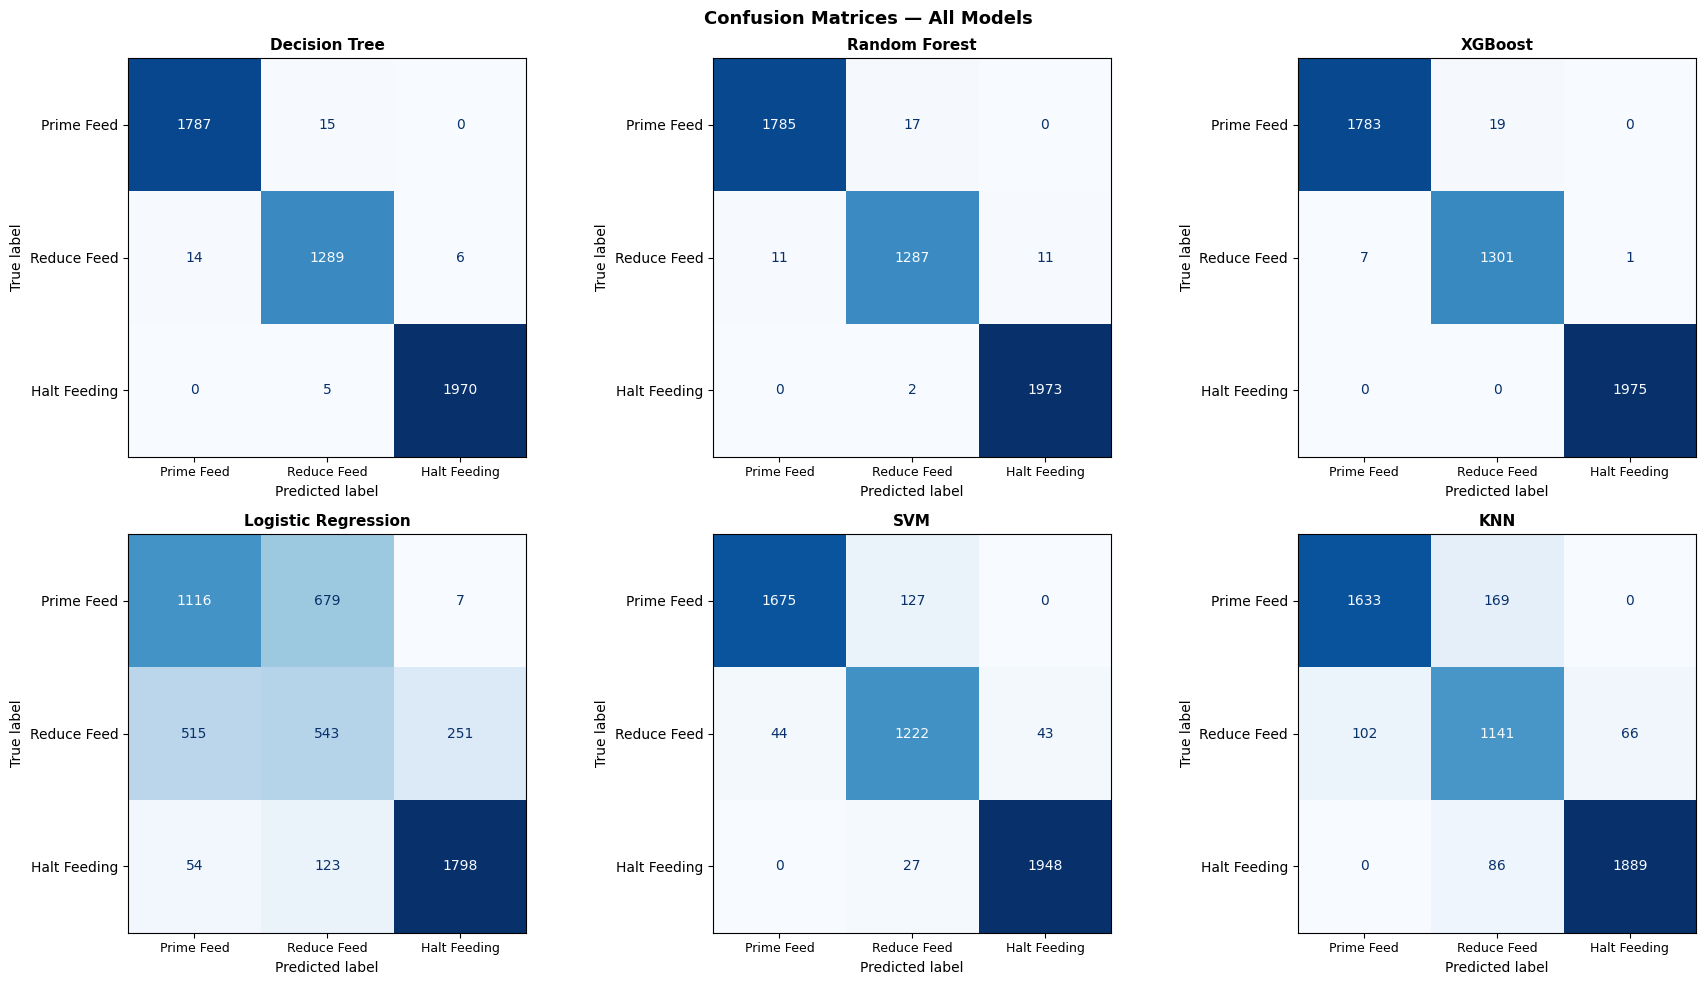

In [14]:
n_models = len(results)
cols     = 3
rows     = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_test, r['y_pred']),
        display_labels=CLASS_NAMES
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

    # Fix x-axis tick labels — horizontal, no slant
    ax.set_xticklabels(CLASS_NAMES, rotation=0, ha='center', fontsize=9)

    # Fix x-axis title
    ax.set_xlabel('Predicted label', rotation=0, fontsize=10)

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

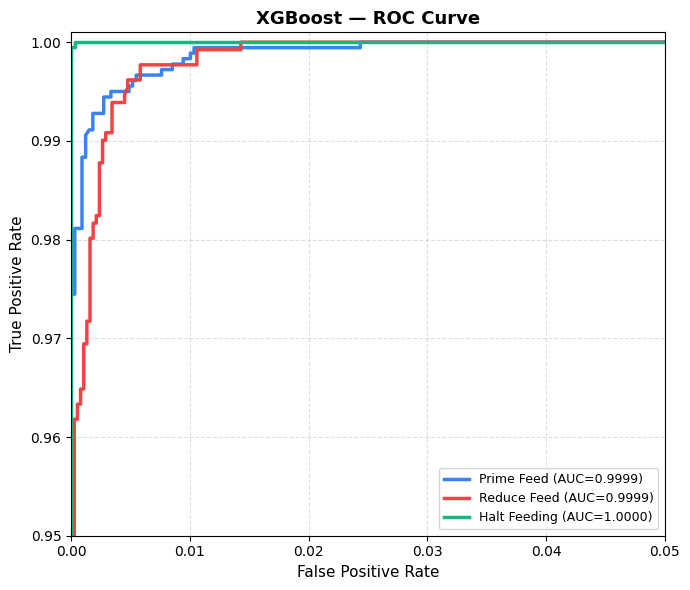

In [22]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors     = ['#3b82f6', '#ef4444', '#10b981']

# Calibrate XGBoost
xgb_model  = results['XGBoost']['model']
calibrated = CalibratedClassifierCV(xgb_model, cv=5, method='isotonic')
calibrated.fit(X_bal, y_bal)
y_score    = calibrated.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(7, 6))

for i, (class_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{class_name} (AUC={roc_auc:.4f})')

ax.set_xlim([0.0, 0.05])
ax.set_ylim([0.95, 1.001])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('XGBoost — ROC Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [1]:
fi = pd.Series(
    best['model'].feature_importances_,
    index=FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi.index, fi.values, color='#3b82f6')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

NameError: name 'pd' is not defined